# Amazon Music Clustering 🎶

### Setup & load data:

In [ ]:
!pip install -q scikit-learn pandas numpy matplotlib seaborn
from google.colab import drive
drive.mount('/content/drive')
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score
import matplotlib.pyplot as plt
import seaborn as sns
import gdown
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 110
np.random.seed(42)

file_id = '1ia1IedigEAYL6NMR4MlQi_HJ7cA1BwuL'
output_path = 'single_genre_artists.csv'
gdown.download(f'https://drive.google.com/uc?id={file_id}', output_path, quiet=False, fuzzy=True)


Mounted at /content/drive


Downloading...
From: https://drive.google.com/uc?id=1ia1IedigEAYL6NMR4MlQi_HJ7cA1BwuL
To: /content/single_genre_artists.csv
100%|██████████| 19.0M/19.0M [00:00<00:00, 26.3MB/s]


'single_genre_artists.csv'

In [ ]:
df = pd.read_csv('single_genre_artists.csv')
df.head()

,id_songs,name_song,popularity_songs,duration_ms,explicit,id_artists,release_date,danceability,energy,key,...,acousticness,instrumentalness,liveness,valence,tempo,time_signature,followers,genres,name_artists,popularity_artists
0,0IA0Hju8CAgYfV1hwhidBH,La Java,0,161427,0,4AxgXfD7ISvJSTObqm4aIE,1922,0.563,0.184,4,...,0.993,0.000016,0.325,0.654,133.088,3,5078.0,['vintage chanson'],Mistinguett,22
1,1b8HZQCqcqwbzlA1jRTp6E,En Douce,0,223440,0,4AxgXfD7ISvJSTObqm4aIE,1922,0.427,0.180,10,...,0.989,0.000000,0.128,0.431,78.459,3,5078.0,['vintage chanson'],Mistinguett,22
2,5d5gQxHwYovxR5pqETOIAa,J'en Ai Marre,0,208267,0,4AxgXfD7ISvJSTObqm4aIE,1922,0.511,0.206,0,...,0.995,0.000000,0.418,0.481,70.443,4,5078.0,['vintage chanson'],Mistinguett,22
3,1EO65UEEPfy7CR0NK2sDxy,Ils n'ont pas ca,0,161933,0,4AxgXfD7ISvJSTObqm4aIE,1924,0.676,0.467,9,...,0.991,0.000000,0.219,0.726,129.775,4,5078.0,['vintage chanson'],Mistinguett,22
4,6a58gXSgqbIsXUhVZ6ZJqe,La belote,0,167973,0,4AxgXfD7ISvJSTObqm4aIE,1924,0.650,0.298,9,...,0.991,0.000000,0.373,0.844,75.950,4,5078.0,['vintage chanson'],Mistinguett,22


### Data exploration & preprocessing:

In [ ]:
print(df.dtypes)

id_songs               object
name_song              object
popularity_songs        int64
duration_ms             int64
explicit                int64
id_artists             object
release_date           object
danceability          float64
energy                float64
key                     int64
loudness              float64
mode                    int64
speechiness           float64
acousticness          float64
instrumentalness      float64
liveness              float64
valence               float64
tempo                 float64
time_signature          int64
followers             float64
genres                 object
name_artists           object
popularity_artists      int64
dtype: object


In [ ]:
print("Missing values per column:")
print(df.isnull().sum())

Missing values per column:
id_songs              0
name_song             0
popularity_songs      0
duration_ms           0
explicit              0
id_artists            0
release_date          0
danceability          0
energy                0
key                   0
loudness              0
mode                  0
speechiness           0
acousticness          0
instrumentalness      0
liveness              0
valence               0
tempo                 0
time_signature        0
followers             0
genres                0
name_artists          0
popularity_artists    0
dtype: int64


In [ ]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [ ]:
# Drop duplicates (none found, but kept for pipeline robustness)
df_clean = df.drop_duplicates().reset_index(drop=True)

# Reference-only columns (not used in clustering, kept for interpretation)
REFERENCE_COLS = ["id_songs", "name_song", "id_artists", "name_artists", "genres"]

FEATURES = ["danceability", "energy", "loudness", "speechiness",
            "acousticness", "instrumentalness", "liveness",
            "valence", "tempo", "duration_ms"]

df_clean[FEATURES].describe().T

,count,mean,std,min,25%,50%,75%,max
danceability,95837.0,0.586853,0.155422,0.00000,0.4880,0.605000,0.7000,0.991
energy,95837.0,0.541083,0.236304,0.00002,0.3650,0.542000,0.7270,1.000
loudness,95837.0,-10.157862,4.748798,-50.17400,-12.7230,-9.397000,-6.6920,5.376
speechiness,95837.0,0.168832,0.275417,0.00000,0.0341,0.046200,0.1030,0.968
acousticness,95837.0,0.458989,0.330416,0.00000,0.1330,0.453000,0.7590,0.996
instrumentalness,95837.0,0.082145,0.232440,0.00000,0.0000,0.000004,0.0013,1.000
liveness,95837.0,0.224916,0.185829,0.00000,0.1000,0.149000,0.3020,0.997
valence,95837.0,0.574281,0.248126,0.00000,0.3780,0.589000,0.7800,1.000
tempo,95837.0,117.539870,30.190399,0.00000,94.8290,116.595000,135.9750,239.906
duration_ms,95837.0,208732.031835,117752.555950,6373.00000,157333.0000,204000.000000,250267.0000,4800118.000


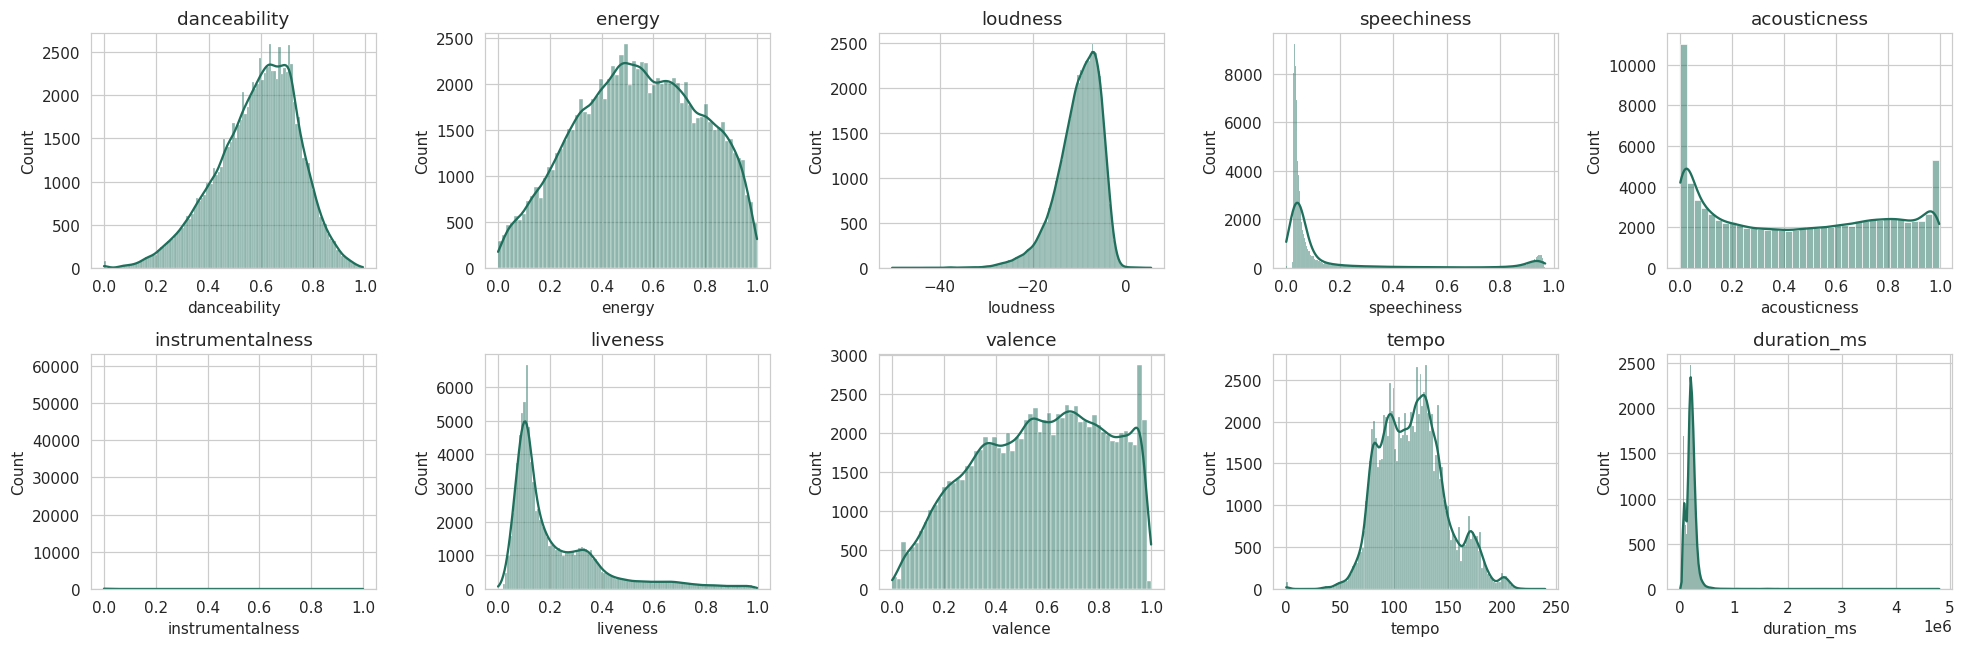

In [ ]:
# Visualize distributions of key features
fig, axes = plt.subplots(2, 5, figsize=(18, 6))
for ax, feat in zip(axes.flat, FEATURES):
    sns.histplot(df_clean[feat], ax=ax, kde=True, color="#1f6f5c")
    ax.set_title(feat)
plt.tight_layout()
plt.show()

**Scaling:** clustering is distance-based, so all features must be on a comparable scale before K-Means.

In [ ]:
X = df_clean[FEATURES].copy()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled[:3]

array([[-0.15347598, -1.51112816, -0.75790895, -0.42710882,  1.61618723,
        -0.35333823,  0.53858362,  0.32128698,  0.51500516, -0.40173462],
       [-1.02851842, -1.52805562, -1.09862851, -0.36974088,  1.60408122,
        -0.35340491, -0.52153664, -0.57745518, -1.2944868 ,  0.12490637],
       [-0.48805103, -1.41802711, -1.12789922, -0.39806176,  1.62224024,
        -0.35340491,  1.03904648, -0.37594348, -1.56000306, -0.00394925]])

### Feature Selection:

We use the 10 features recommended in the project brief — they jointly describe a song's
**rhythm, mood, instrumentation, and energy**, which is exactly what defines audio-based
"genre/mood" similarity:

`danceability, energy, loudness, speechiness, acousticness, instrumentalness, liveness, valence, tempo, duration_ms`

No additional feature engineering was needed — the dataset is clean (no nulls, no duplicates).

### Dimensionality reduction (PCA):

In [ ]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Total variance captured by 2 PCs:", pca.explained_variance_ratio_.sum())

Explained variance ratio: [0.27079553 0.18821441]
Total variance captured by 2 PCs: 0.459009939910359


### Clustering:

#### Choosing k - Elbow method + Silhouette score
we sweep the k from 2 to 10, recording inertia (for the elbow plot) and the silhouette score (on an 8000-song sample, for speed), for each

In [ ]:
sample_idx = np.random.RandomState(42).choice(len(X_scaled), size=8000, replace=False)
X_sample = X_scaled[sample_idx]

k_range = range(2, 11)
inertias, sil_scores = [], []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)
    sample_labels = km.predict(X_sample)
    sil_scores.append(silhouette_score(X_sample, sample_labels))
    print(f"k={k}: inertia={km.inertia_:.1f}, silhouette={sil_scores[-1]:.4f}")

k=2: inertia=778813.6, silhouette=0.2007
k=3: inertia=658335.1, silhouette=0.2379
k=4: inertia=593031.0, silhouette=0.2270
k=5: inertia=548594.9, silhouette=0.1862
k=6: inertia=520710.6, silhouette=0.1575
k=7: inertia=486936.4, silhouette=0.1878
k=8: inertia=460215.4, silhouette=0.1669
k=9: inertia=439036.7, silhouette=0.1664
k=10: inertia=415491.7, silhouette=0.1745


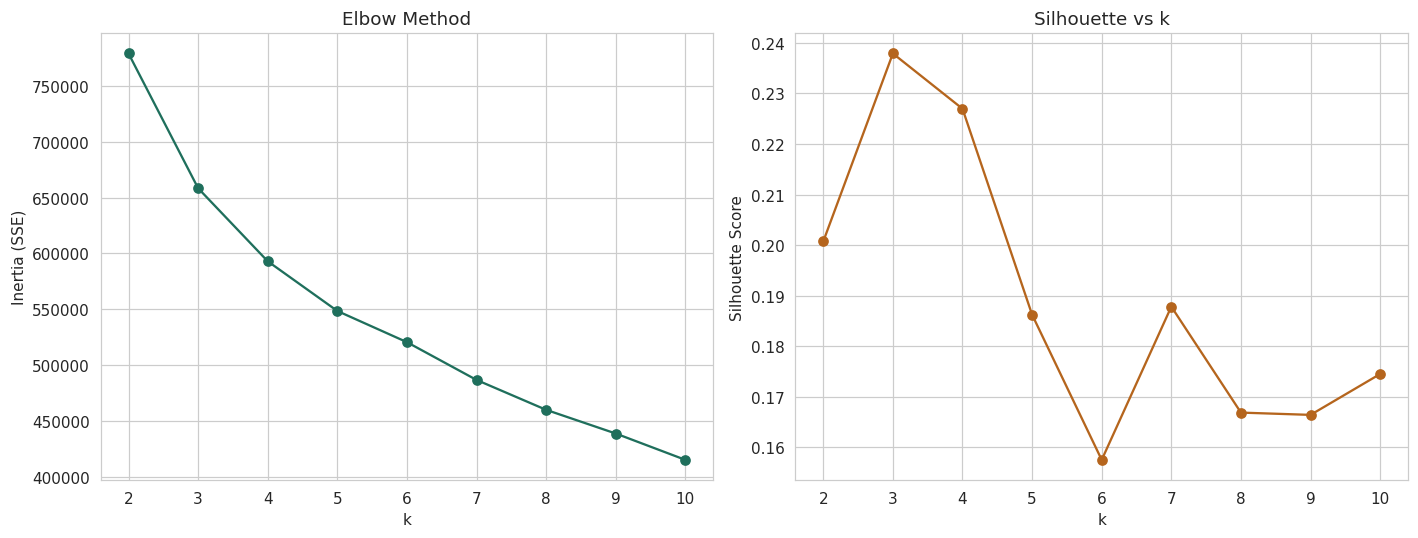

Best k by silhouette score: 3


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(list(k_range), inertias, marker="o", color="#1f6f5c")
axes[0].set_xlabel("k"); axes[0].set_ylabel("Inertia (SSE)"); axes[0].set_title("Elbow Method")

axes[1].plot(list(k_range), sil_scores, marker="o", color="#b5651d")
axes[1].set_xlabel("k"); axes[1].set_ylabel("Silhouette Score"); axes[1].set_title("Silhouette vs k")
plt.tight_layout()
plt.show()

best_k = list(k_range)[int(np.argmax(sil_scores))]
print("Best k by silhouette score:", best_k)

**Result:** both the elbow plot (diminishing returns after k≈3-4) and the silhouette
score (peaks at k=3) agree that **k=3** is the most statistically defensible choice for this
feature set. Higher k values produce more granular but less *well-separated* clusters.

#### Final k-means model

In [ ]:
CHOSEN_K = 3  # informed by elbow + silhouette analysis above

kmeans = KMeans(n_clusters=CHOSEN_K, random_state=42, n_init=10)
df_clean["cluster"] = kmeans.fit_predict(X_scaled)

df_clean["cluster"].value_counts().sort_index()

,count
cluster,
0,12513
1,30807
2,52517


### Cluster Evaluation:

In [ ]:
final_sil = silhouette_score(X_scaled[sample_idx], df_clean.loc[sample_idx, "cluster"])
final_db = davies_bouldin_score(X_scaled, df_clean["cluster"])

print(f"Silhouette Score (8k sample): {final_sil:.4f}")
print(f"Davies-Bouldin Index (full data): {final_db:.4f}")

Silhouette Score (8k sample): 0.2379
Davies-Bouldin Index (full data): 1.5702


Silhouette score -> ~0.24 [ Moderate, well defined separation for real-world audio data (1 = perfect, 0 = overlapping) ]

Davies-Bouldin Index -> ~1.57 [ Lower is better, reasonable given overlap in musical style

**Note:** Real-world audio features are continuous and genre boundaries are inherently fuzzy (a song can be both danceable
*and* acoustic) — a silhouette score in the 0.2–0.3 range is typical and expected for this kind of data,
not a sign of a failed model.

### Visualization:

PCA:

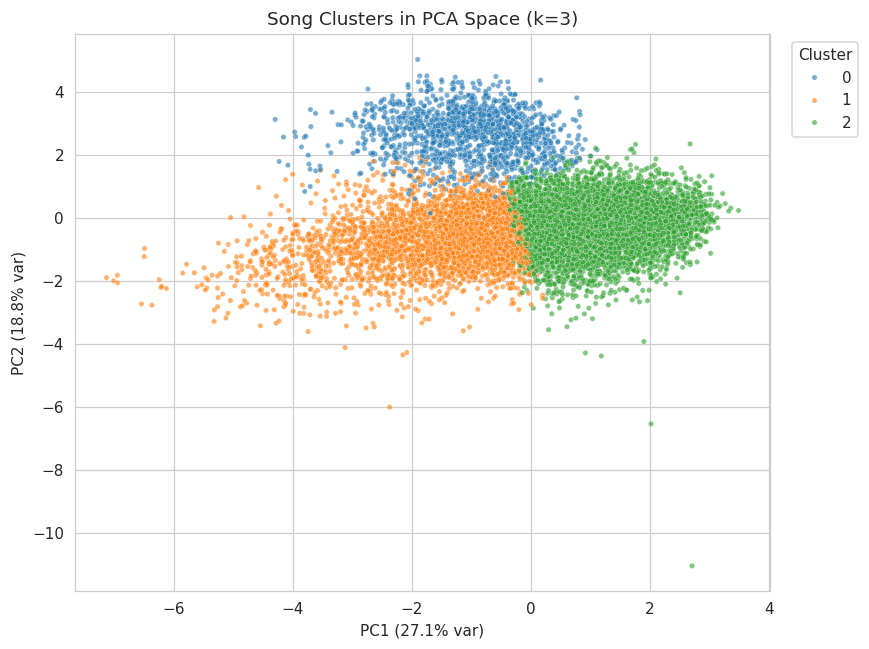

In [ ]:
df_plot = df_clean.sample(min(10000, len(df_clean)), random_state=1).copy()
df_plot["pca1"] = pca.transform(X_scaled[df_plot.index])[:, 0]
df_plot["pca2"] = pca.transform(X_scaled[df_plot.index])[:, 1]

plt.figure(figsize=(8, 6))
sns.scatterplot(data=df_plot, x="pca1", y="pca2", hue="cluster",
                 palette=sns.color_palette("tab10", CHOSEN_K), s=12, alpha=0.6)
plt.title(f"Song Clusters in PCA Space (k={CHOSEN_K})")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)")
plt.legend(title="Cluster", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [ ]:
profile = df_clean.groupby("cluster")[FEATURES].mean().round(3)
profile["size"] = df_clean["cluster"].value_counts().sort_index()
profile["pct"] = (profile["size"] / len(df_clean) * 100).round(2)
profile

,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,size,pct
cluster,,,,,,,,,,,,
0,0.664,0.467,-13.364,0.830,0.586,0.001,0.436,0.584,100.389,97520.590,12513,13.06
1,0.486,0.311,-13.205,0.060,0.749,0.169,0.182,0.413,111.940,223457.064,30807,32.15
2,0.627,0.694,-7.606,0.075,0.258,0.051,0.200,0.666,124.911,226592.053,52517,54.80


Heatmap:

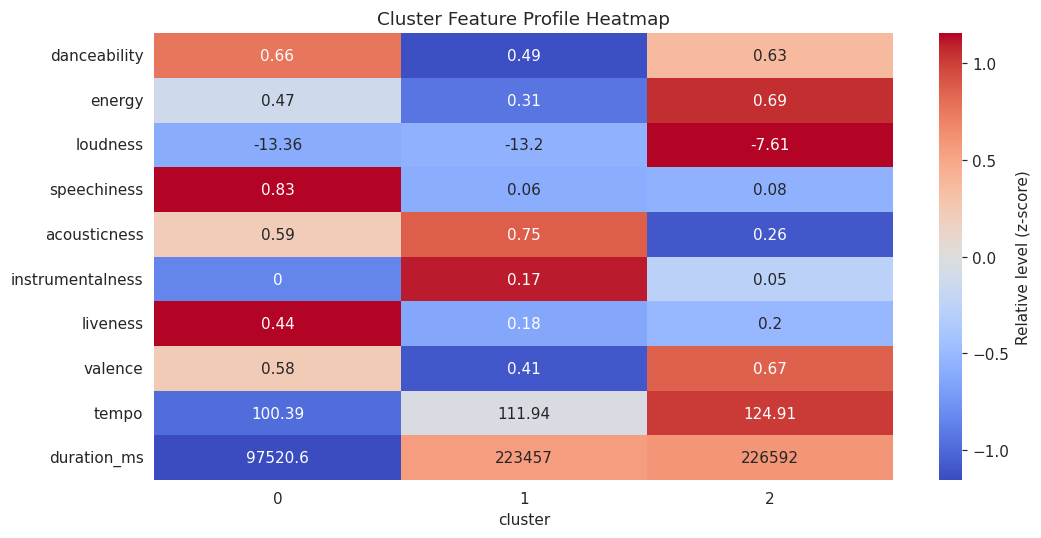

In [ ]:
profile_z = (profile[FEATURES] - profile[FEATURES].mean()) / profile[FEATURES].std()
plt.figure(figsize=(10, 5))
sns.heatmap(profile_z.T, annot=profile[FEATURES].T.round(2), fmt="g", cmap="coolwarm", center=0,
            cbar_kws={"label": "Relative level (z-score)"})
plt.title("Cluster Feature Profile Heatmap")
plt.tight_layout()
plt.show()

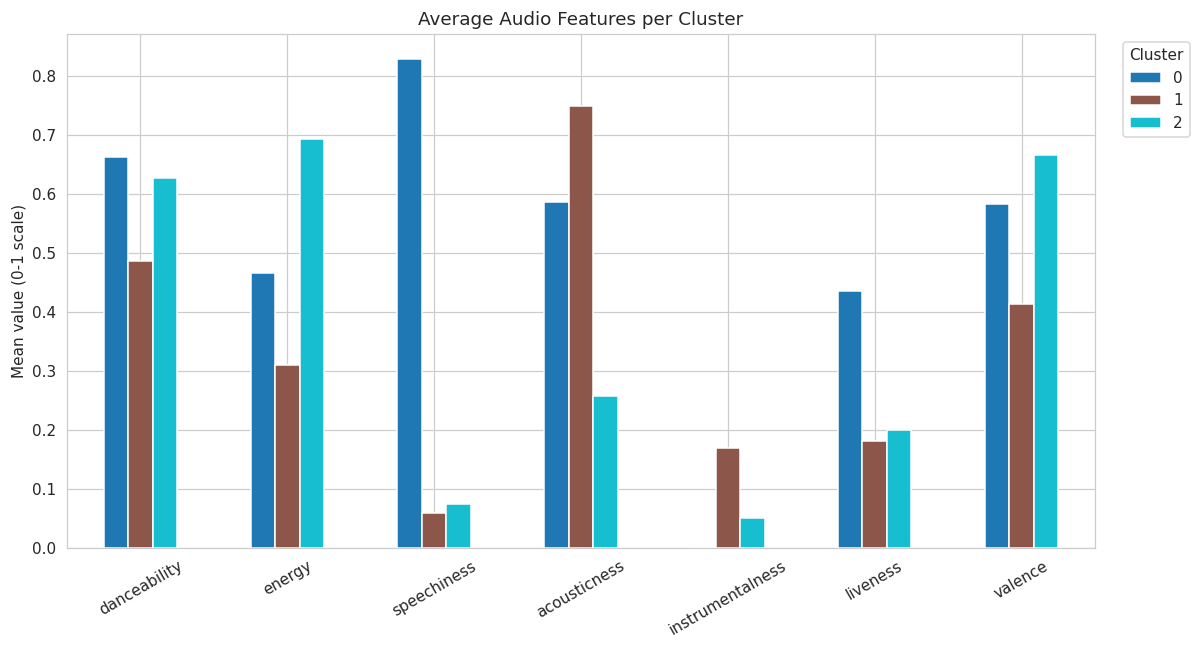

In [ ]:
norm_features = ["danceability", "energy", "speechiness", "acousticness",
                  "instrumentalness", "liveness", "valence"]
profile[norm_features].T.plot(kind="bar", figsize=(11, 6), colormap="tab10")
plt.title("Average Audio Features per Cluster")
plt.ylabel("Mean value (0-1 scale)")
plt.legend(title="Cluster", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

Distributions:

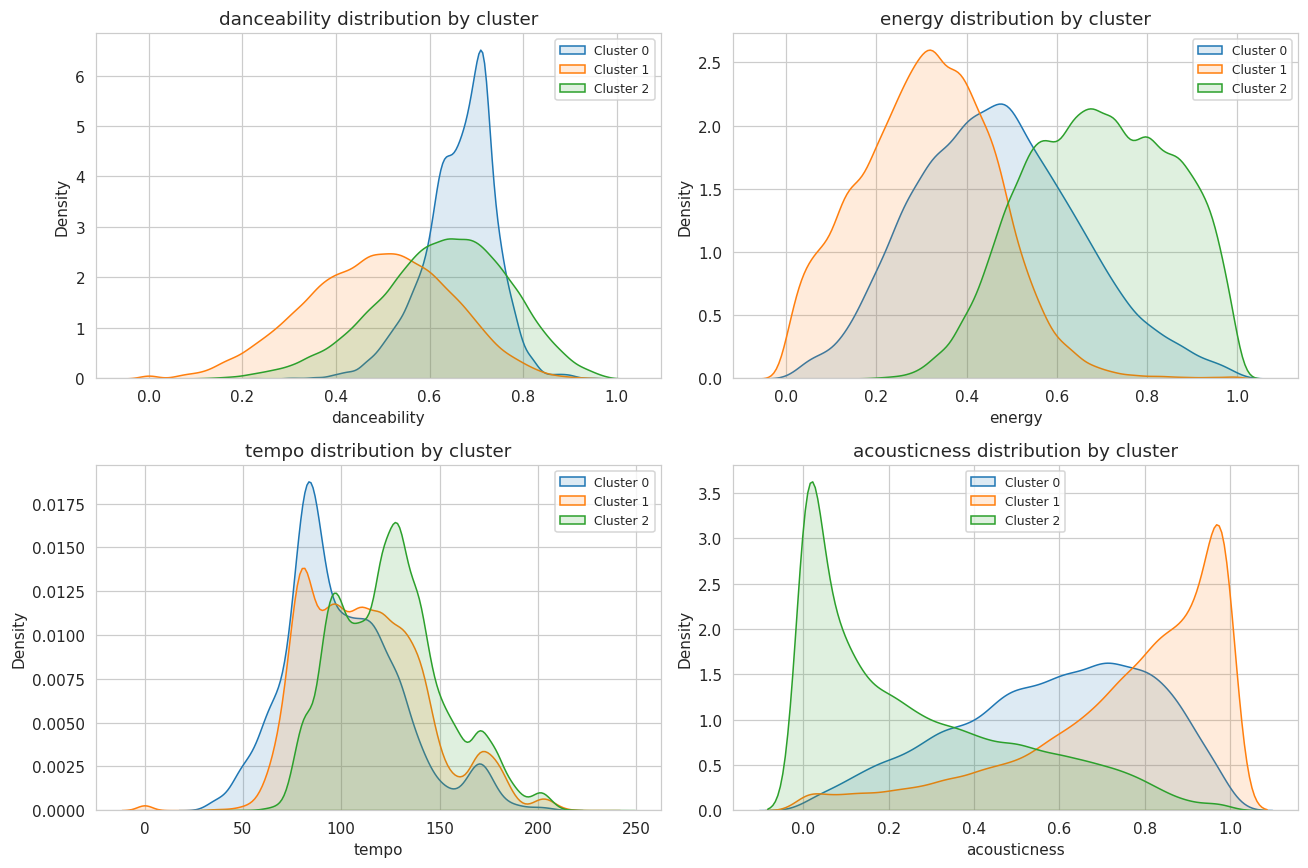

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, feat in zip(axes.flat, ["danceability", "energy", "tempo", "acousticness"]):
    for c in sorted(df_clean["cluster"].unique()):
        sns.kdeplot(df_clean[df_clean["cluster"] == c][feat], ax=ax, label=f"Cluster {c}", fill=True, alpha=0.15)
    ax.set_title(f"{feat} distribution by cluster")
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## 7. Cluster Interpretation & Business Labels

Reading the profile table and heatmap above:

| Cluster | Size | Key traits | Suggested label |
|---|---|---|---|
| **0** | 13.1% | Speechiness ≈ **0.83** (very high), shortest avg. duration (~98s), moderate dance/energy | **Spoken-Word / Short-Form Talk Tracks** (interludes, comedy, poetry, rap-adjacent vocal tracks) |
| **1** | 32.2% | Acousticness ≈ 0.75, low energy (0.31), lower valence (0.41), low speechiness | **Acoustic / Mellow Ballads** |
| **2** | 54.8% | Low acousticness (0.26), high energy (0.69), high valence (0.67), fastest tempo (125 bpm), loudest | **Upbeat / High-Energy Dance Tracks** (mainstream pop/dance majority) |

**Business takeaways:**
- **Personalized playlists:** Cluster 2 is the natural "workout/party" playlist seed; Cluster 1 the "chill/focus" seed.
- **Song discovery:** Within-cluster nearest neighbors (by scaled feature distance) make strong "similar track" recommendations.
- **Market segmentation:** Cluster 0's spoken-word profile suggests a distinct content type (not music in the traditional sense) — useful for filtering recommendation engines that should only surface music.
- **Artist analysis:** an artist's cluster mix shows how varied (or formulaic) their catalog is.


In [ ]:
# Top tracks per cluster (by popularity, if available) for a quick sanity check
if "popularity_songs" in df_clean.columns:
    for c in sorted(df_clean["cluster"].unique()):
        print(f"\n--- Cluster {c} top tracks ---")
        top = df_clean[df_clean["cluster"] == c].sort_values("popularity_songs", ascending=False)
        print(top[["name_song", "name_artists", "popularity_songs"]].head(5).to_string(index=False))


--- Cluster 0 top tracks ---
                     name_song  name_artists  popularity_songs
Beautiful Pain (Losin My Mind)        Polo G                72
                  Siempre Fine        Ak4:20                72
                     Gentleman            SL                70
                    Neva Cared        Polo G                70
         The Chicken Wing Beat Ricky Desktop                70

--- Cluster 1 top tracks ---
          name_song     name_artists  popularity_songs
             Arcade  Duncan Laurence                89
Put Your Records On      Ritt Momney                87
             Arcade  Duncan Laurence                83
            Hold On Chord Overstreet                83
            Control         Zoe Wees                80

--- Cluster 2 top tracks ---
              name_song  name_artists  popularity_songs
 Astronaut In The Ocean   Masked Wolf                98
            WITHOUT YOU The Kid LAROI                94
           Hecha Pa' Mi          B

### Final Export:

In [ ]:
export_cols = [c for c in df_clean.columns if c not in ("pca1", "pca2")]
df_clean[export_cols].to_csv("amazon_music_clustered_output.csv", index=False)
print("Saved amazon_music_clustered_output.csv with shape:", df_clean[export_cols].shape)

Saved amazon_music_clustered_output.csv with shape: (95837, 24)
